# Лабораторная работа №4. Использование Dask для ETL-процессов (Google Colab)
**Вариант 2**

**Цель работы:** получить практические навыки работы с библиотекой Dask для построения базовых ETL-конвейеров при обработке больших массивов данных. Изучить принципы «ленивых вычислений» и визуализацию графов (DAG).

In [1]:
# 1. Установка Dask с полным набором зависимостей
!pip install "dask[complete]" graphviz pyarrow altair

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.7 MB/s eta 0:00:00


In [2]:
import dask.dataframe as dd
from dask.distributed import Client
from dask.diagnostics import ProgressBar
import dask.delayed as delayed
import os
import pandas as pd
import altair as alt
import re
from datetime import datetime

# Инициализация клиента Dask
client = Client(n_workers=2, threads_per_worker=2, memory_limit='4GB')
client

INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:41165
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:46021'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:36337'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:34345 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:34345
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:33892
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:40469 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:40469
INFO:distributed.core:Starting established connection to tcp://127

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 2
Total threads: 4,Total memory: 7.45 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41165,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:34345,Total threads: 2
Dashboard: http://127.0.0.1:32975/status,Memory: 3.73 GiB
Nanny: tcp://127.0.0.1:46021,


# Шаг 1. Extract (Извлечение данных)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
dtype_dict = {
    'Summons Number': 'int64',
    'Plate ID': 'object',
    'Registration State': 'object',
    'Plate Type': 'object',
    'Issue Date': 'object',
    'Violation Code': 'int64',
    'Vehicle Body Type': 'object',
    'Vehicle Make': 'object',
    'Issuing Agency': 'object',
    'Issuer Code': 'int64',
    'Issuer Command': 'object',
    'Issuer Squad': 'object',
    'Violation Time': 'object',
    'Time First Observed': 'object',
    'Violation County': 'object',
    'Violation In Existence Only Flag': 'object',
    'House Number': 'object',
    'Street Name': 'object',
    'Intersecting Street': 'object',
    'Sub Division': 'object',
    'Violation Legal Code': 'object',
    'Days Parking In Effect    ': 'object',
    'From Hours In Effect': 'object',
    'To Hours In Effect': 'object',
    'Vehicle Color': 'object',
    'Meter Number': 'object',
    'Violation Post Code': 'object',
    'Violation Description': 'object',
    'Double Parking Violation': 'object',
    'Hydrant Violation': 'object',
    'No Standing or Stopping Violation': 'object'
}

filename = '/content/drive/MyDrive/Parking_Violations_Issued_-_Fiscal_Year_2015.csv'
df = dd.read_csv(filename, dtype=dtype_dict, blocksize="64MB", on_bad_lines='skip', assume_missing=True)
df

,Summons Number,Plate ID,Registration State,Plate Type,Issue Date,Violation Code,Vehicle Body Type,Vehicle Make,Issuing Agency,Street Code1,Street Code2,Street Code3,Vehicle Expiration Date,Violation Location,Violation Precinct,Issuer Precinct,Issuer Code,Issuer Command,Issuer Squad,Violation Time,Time First Observed,Violation County,Violation In Front Of Or Opposite,House Number,Street Name,Intersecting Street,Date First Observed,Law Section,Sub Division,Violation Legal Code,Days Parking In Effect,From Hours In Effect,To Hours In Effect,Vehicle Color,Unregistered Vehicle?,Vehicle Year,Meter Number,Feet From Curb,Violation Post Code,Violation Description,No Standing or Stopping Violation,Hydrant Violation,Double Parking Violation,Latitude,Longitude,Community Board,Community Council,Census Tract,BIN,BBL,NTA
npartitions=44,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
,int64,string,string,string,string,int64,string,string,string,float64,float64,float64,string,float64,float64,float64,int64,string,string,string,string,string,string,string,string,string,string,float64,string,string,string,string,string,string,float64,float64,string,float64,string,string,string,string,string,float64,float64,float64,float64,float64,float64,float64,float64
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


### Шаг 2. Transform (Трансформация и очистка данных)

In [9]:
missing_values = df.isnull().sum()
mysize = df.index.size
missing_count_percent = (missing_values / mysize) * 100

with ProgressBar():
    missing_percent_computed = missing_count_percent.compute()

columns_to_drop = list(missing_percent_computed[missing_percent_computed > 60].index)
df_dropped = df.drop(columns=columns_to_drop)
df_dropped.head()

,Summons Number,Plate ID,Registration State,Plate Type,Issue Date,Violation Code,Vehicle Body Type,Vehicle Make,Issuing Agency,Street Code1,...,Law Section,Sub Division,Days Parking In Effect,From Hours In Effect,To Hours In Effect,Vehicle Color,Vehicle Year,Feet From Curb,Violation Post Code,Violation Description
0,8002531292,EPC5238,NY,PAS,10/01/2014,21,SUBN,CHEVR,T,20390.0,...,408.0,d1,Y Y Y,1200A,0300A,BL,2005.0,0.0,A 77,21-No Parking (street clean)
1,8015318440,5298MD,NY,COM,03/06/2015,14,VAN,FRUEH,T,27790.0,...,408.0,c,YYYYY,0700A,1000A,BROWN,0.0,0.0,CC3,14-No Standing
2,7611181981,FYW2775,NY,PAS,07/28/2014,46,SUBN,SUBAR,T,8130.0,...,408.0,f1,<NA>,<NA>,<NA>,BLACK,2010.0,0.0,J 32,46A-Double Parking (Non-COM)
3,7445908067,GWE1987,NY,PAS,04/13/2015,19,4DSD,LEXUS,T,59990.0,...,408.0,c3,YYYYY,0300P,1000P,GY,2015.0,0.0,01 4,19-No Stand (bus stop)
4,7037692864,T671196C,NY,PAS,05/19/2015,19,4DSD,CHRYS,T,36090.0,...,408.0,c3,YYYYYYY,<NA>,<NA>,BLACK,0.0,0.0,19 7,19-No Stand (bus stop)


### Шаг 3. Load (Загрузка / Сохранение результатов)

In [10]:
output_path = '/content/drive/MyDrive/cleaned_data_2015_v2.parquet'
with ProgressBar():
    df_dropped.to_parquet(output_path, engine='pyarrow', overwrite=True)

csv_output = '/content/drive/MyDrive/cleaned_violations_2015_v2.csv'
with ProgressBar():
    df_dropped.to_csv(csv_output, single_file=True, index=False)

print("Данные сохранены в Parquet и CSV.")

Данные сохранены в Parquet и CSV.


## Задание 4.2. Визуализация направленных ациклических графов (DAG)

### 4.2.1. Простой DAG

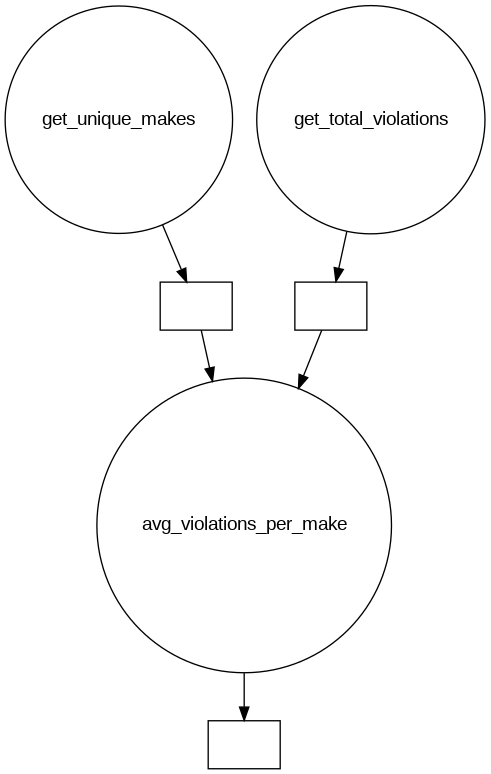

INFO:distributed.scheduler:Receive client connection: Client-worker-5750fde5-2a02-11f1-8544-0242ac1c000c
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:51368
INFO:distributed.scheduler:Receive client connection: Client-worker-57514622-2a02-11f1-8540-0242ac1c000c


Граф сохранен как 'simple_violation_analysis.png'


INFO:distributed.core:Starting established connection to tcp://127.0.0.1:51360


Результат вычисления DAG: 1690.9


Среднее количество нарушений на марку: 1690.9


In [12]:
from dask import delayed
from IPython.display import Image
import dask.dataframe as dd

# Функции для анализа
def get_total_violations():
    return len(df_dropped)

def get_unique_makes():
    # Вычисляем уникальные марки
    return df_dropped['Vehicle Make'].nunique().compute()

def avg_violations_per_make(total, unique):
    if unique == 0:
        return 0
    return round(total / unique, 2)

# Создаем узлы DAG
x = delayed(get_total_violations)()
y = delayed(get_unique_makes)()
z = delayed(avg_violations_per_make)(x, y)

# Визуализация
try:
    # Визуализируем граф
    z.visualize(filename='simple_violation_analysis.png', rankdir='TB')
    display(Image('simple_violation_analysis.png'))
    print("Граф сохранен как 'simple_violation_analysis.png'")
except Exception as e:
    print(f"Graphviz ошибка: {e}")
    print("Для визуализации установите graphviz: !apt-get install graphviz")

print("Результат вычисления DAG:", z.compute())
print(f"Среднее количество нарушений на марку: {z.compute()}")

### 4.2.2. Сложный многоуровневый DAG

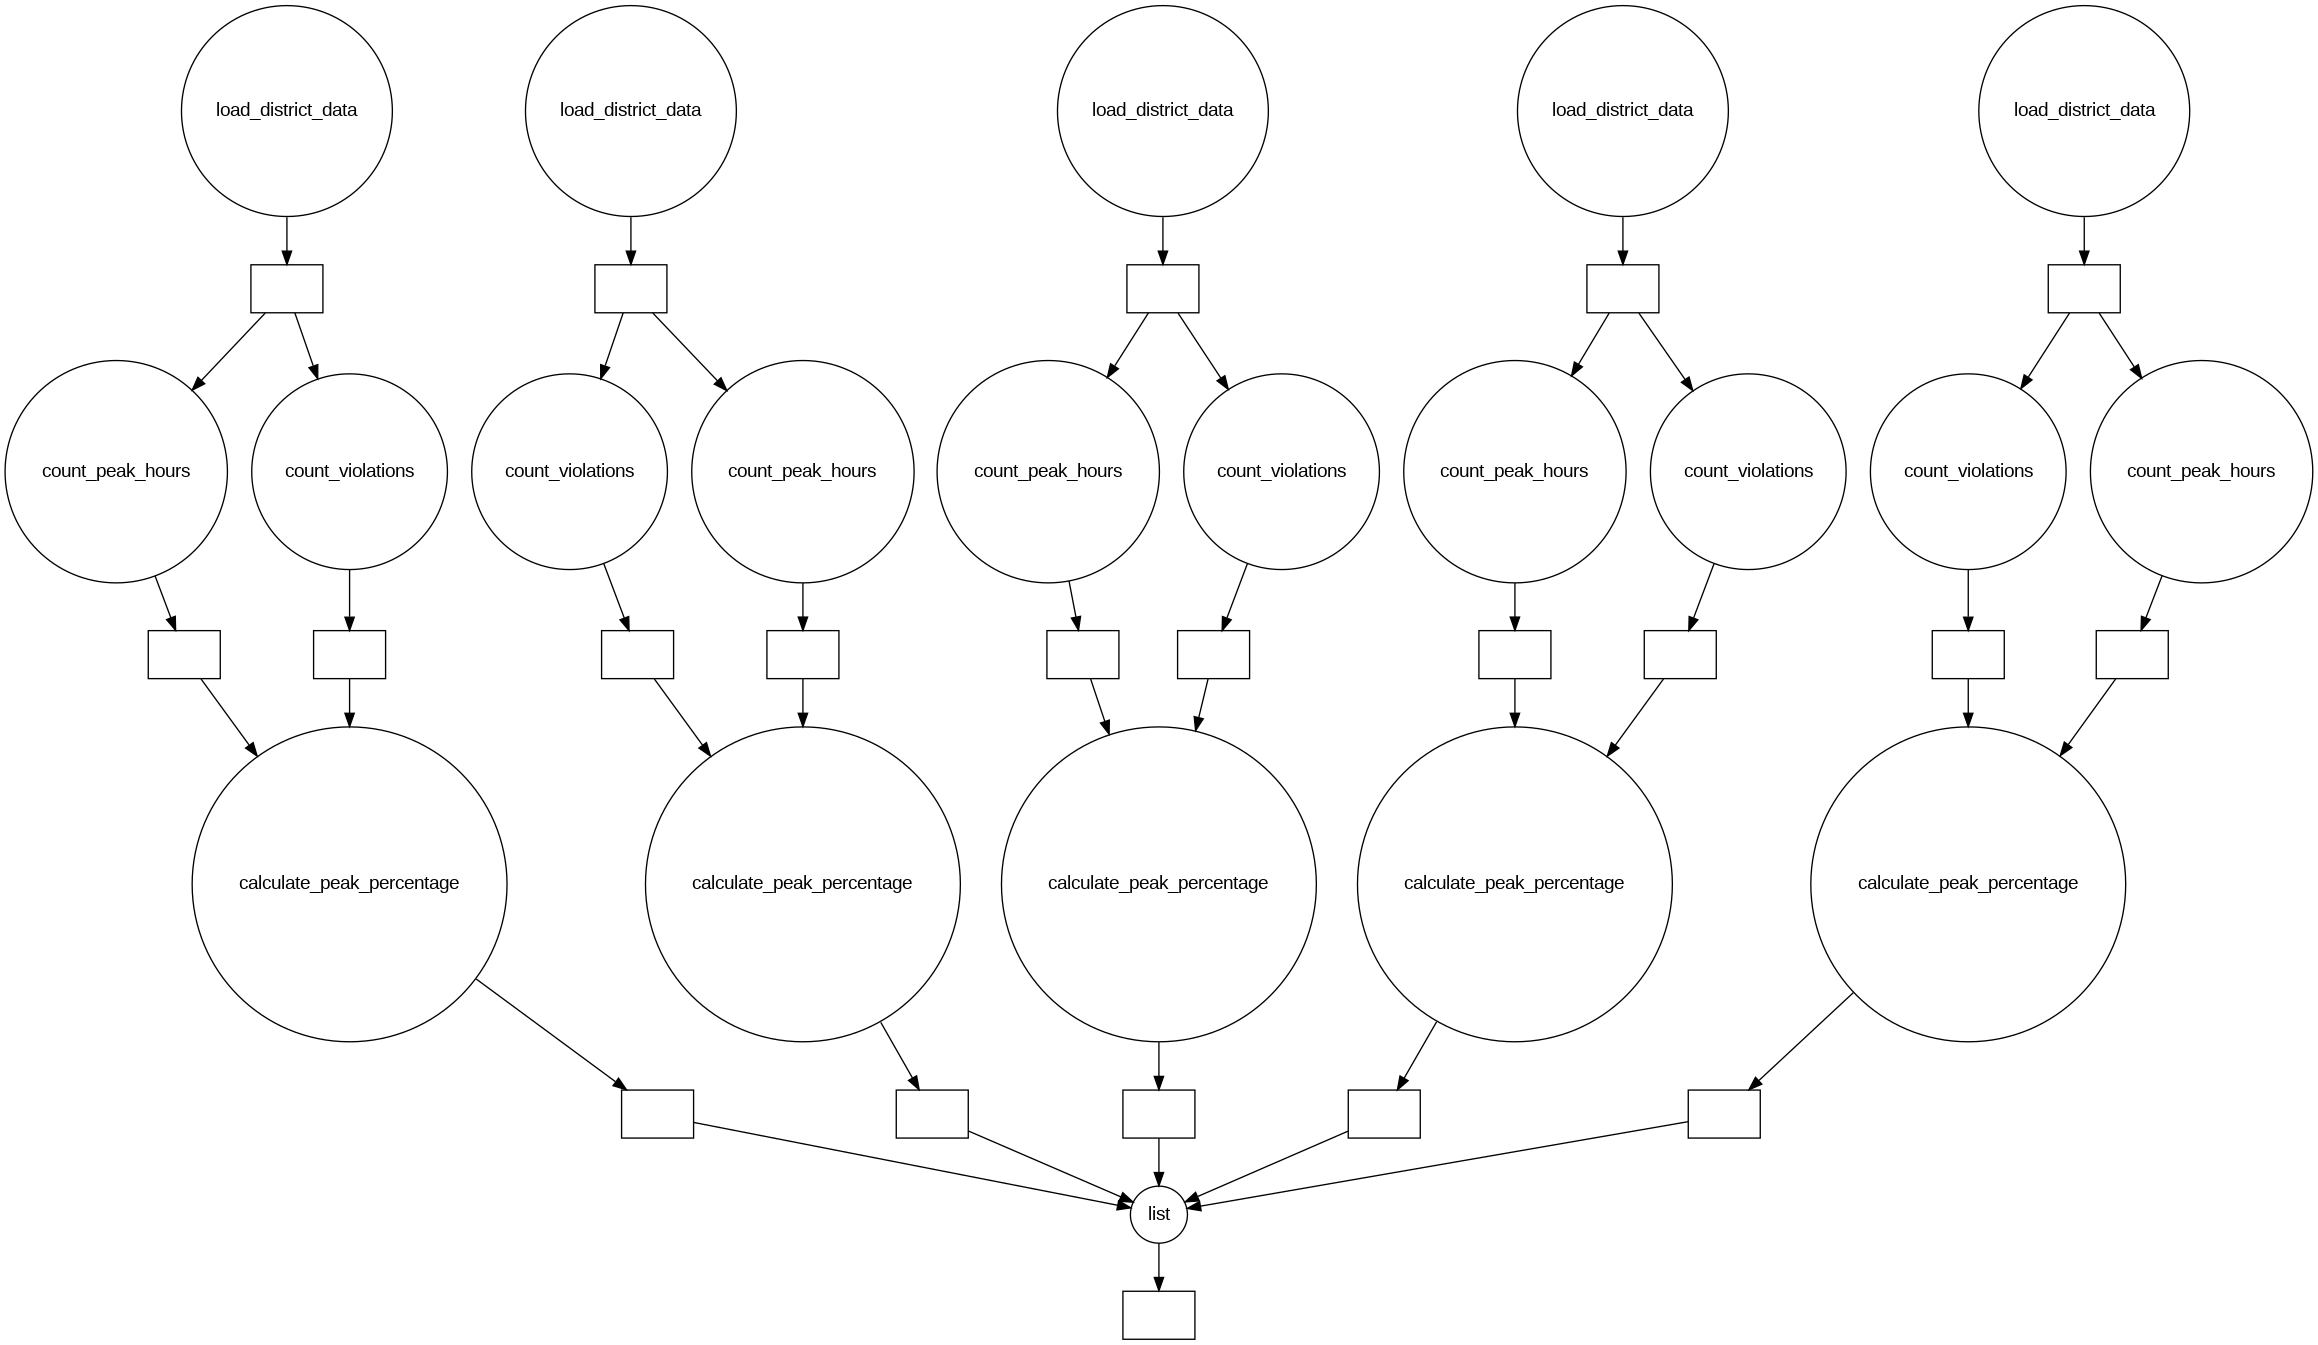

Сложный граф сохранен как 'complex_district_analysis.png'


INFO:distributed.nanny:Worker process 1344 exited with status 1
INFO:distributed.nanny:Closing Nanny at 'tcp://127.0.0.1:46021'. Reason: nanny-close-gracefully
INFO:distributed.nanny:Nanny at 'tcp://127.0.0.1:46021' closed.
INFO:distributed.nanny:Worker process 1348 exited with status 1
INFO:distributed.nanny:Closing Nanny at 'tcp://127.0.0.1:36337'. Reason: nanny-close-gracefully
INFO:distributed.nanny:Nanny at 'tcp://127.0.0.1:36337' closed.
ERROR:asyncio:Task exception was never retrieved
future: <Task finished name='Task-646589' coro=<Client._gather.<locals>.wait() done, defined at /usr/local/lib/python3.12/dist-packages/distributed/client.py:2388> exception=AllExit()>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/distributed/client.py", line 2397, in wait
    raise AllExit()
distributed.client.AllExit


KeyboardInterrupt: 

In [14]:
from dask import delayed
from IPython.display import Image
import pandas as pd

# Список районов для анализа
districts = ['NY', 'K', 'Q', 'BX', 'R']
district_names = {
    'NY': 'Manhattan',
    'K': 'Brooklyn',
    'Q': 'Queens',
    'BX': 'Bronx',
    'R': 'Staten Island'
}

def load_district_data(district):
    """Загрузка данных по району"""
    return df_dropped[df_dropped['Violation County'] == district]

def count_violations(district_data):
    """Подсчет общего количества нарушений"""
    if district_data is None or len(district_data) == 0:
        return 0
    return len(district_data)

def count_peak_hours(district_data):
    """Подсчет нарушений в часы пик (8-10 утра)"""
    if district_data is None or len(district_data) == 0:
        return 0

    # Извлекаем часы из Violation Time
    # Преобразуем в строку и берем первые 2 символа
    hours = district_data['Violation Time'].astype(str).str[:2]

    # Часы пик: 08, 09, 10
    peak_hours = hours[hours.isin(['08', '09', '10'])]
    return len(peak_hours)

def calculate_peak_percentage(total, peak):
    """Расчет процента нарушений в часы пик"""
    if total == 0:
        return 0
    return round((peak / total) * 100, 2)

# Создаем многоуровневый DAG
# Уровень 1: Загрузка данных по каждому району
layer1 = [delayed(load_district_data)(d) for d in districts]

# Уровень 2: Параллельный подсчет нарушений
layer2 = [delayed(count_violations)(d) for d in layer1]

# Уровень 3: Параллельный подсчет нарушений в часы пик
layer3 = [delayed(count_peak_hours)(d) for d in layer1]

# Уровень 4: Расчет процентов
layer4 = [delayed(calculate_peak_percentage)(t, p) for t, p in zip(layer2, layer3)]

# Собираем результаты
results = delayed(list)(layer4)

# Визуализация сложного графа
try:
    # Сохраняем граф с иерархической структурой
    results.visualize(
        filename='complex_district_analysis.png',
        rankdir='TB',  # Top to Bottom orientation
    )
    display(Image('complex_district_analysis.png'))
    print("Сложный граф сохранен как 'complex_district_analysis.png'")
except Exception as e:
    print(f"Graphviz ошибка: {e}")

# Вычисляем результаты
final_results = results.compute()

print("\n=== Результаты анализа по районам ===")
print("Район\t\tОбщее количество\tЧасы пик (%)\t\tРайон")
print("-" * 70)
for i, district in enumerate(districts):
    district_name = district_names.get(district, district)
    total = layer2[i].compute()  # Вычисляем общее количество
    peak_percent = final_results[i]

    print(f"{district_name:<15}\t{total:<16}\t{peak_percent}%\t\t{district}")

# Дополнительный анализ: находим район с наибольшим процентом нарушений в часы пик
max_idx = final_results.index(max(final_results))
print(f"\nНаибольший процент нарушений в часы пик: {district_names[districts[max_idx]]} ({final_results[max_idx]}%)")

## 5. Анализ и визуализация данных (Altair)

В данном разделе выполняется построение интерактивных графиков для анализа NYC Parking Violations.

In [16]:
df_viz = pd.read_csv(csv_output, parse_dates=['Issue Date'], nrows=20000)
df_viz['Issue Date'] = pd.to_datetime(df_viz['Issue Date'], errors='coerce')
df_viz = df_viz.dropna(subset=['Issue Date'])
df_viz['Day of Week'] = df_viz['Issue Date'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

print("Подготовка данных завершена.")

Подготовка данных завершена.


Всего записей: 20,000


alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

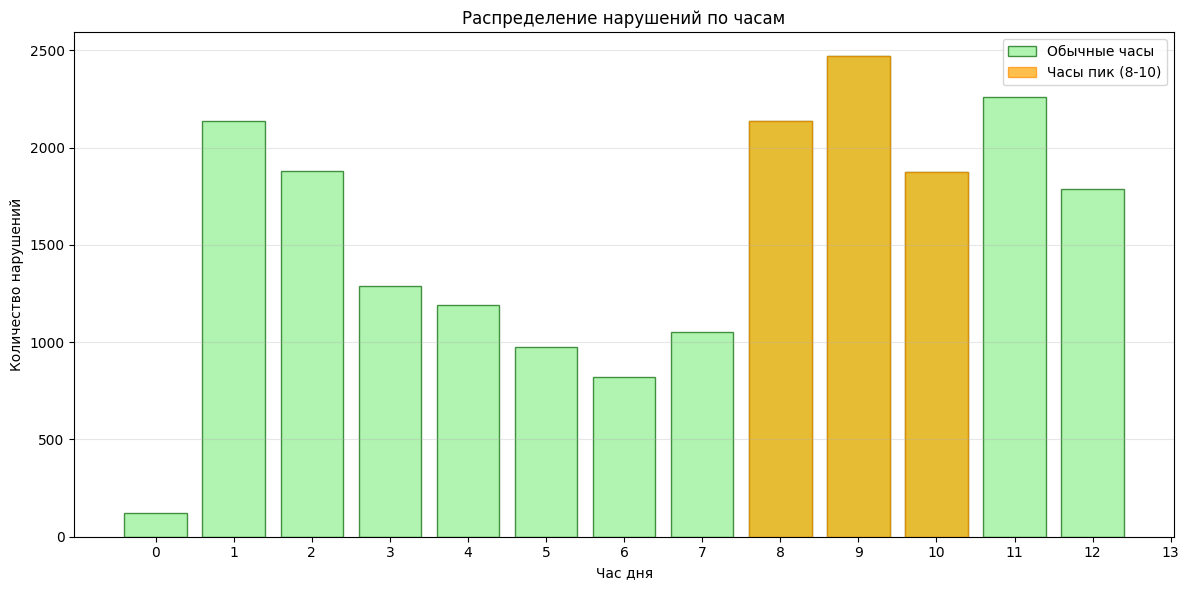


📊 Статистика:
Общее количество нарушений: 20,000
Среднее количество нарушений в день: 2857
Наиболее активный день: 5 (3,612 нарушений)
Наименее активный день: 3 (761 нарушений)


In [21]:
import altair as alt
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Включаем режим работы с большими данными Altair
alt.data_transformers.enable('default', max_rows=None)

print(f"Всего записей: {len(df_viz):,}")

# График 1: Топ-10 марок (Altair)
top_makes = df_viz['Vehicle Make'].value_counts().reset_index().head(10)
top_makes.columns = ['Make', 'Count']

chart1 = alt.Chart(top_makes).mark_bar().encode(
    x=alt.X('Count:Q', title='Количество нарушений'),
    y=alt.Y('Make:N', sort='-x', title='Марка автомобиля'),
    color='Count:Q',
    tooltip=['Make', 'Count']
).properties(title='Топ-10 марок автомобилей по количеству нарушений', width=600)

display(chart1)

# График 2: Нарушения по дням недели (Altair с агрегацией)
daily_counts = df_viz.groupby('Day of Week').size().reset_index(name='count')
daily_counts['Day of Week'] = pd.Categorical(
    daily_counts['Day of Week'],
    categories=day_order,
    ordered=True
)
daily_counts = daily_counts.sort_values('Day of Week')

chart2 = alt.Chart(daily_counts).mark_bar().encode(
    x=alt.X('Day of Week:N', title='День недели'),
    y=alt.Y('count:Q', title='Количество нарушений'),
    color='Day of Week:N',
    tooltip=['Day of Week', 'count']
).properties(title='Распределение нарушений по дням недели', width=600)

display(chart2)

# График 3: Топ-10 типов нарушений (Altair)
top_violations = df_viz['Violation Description'].value_counts().reset_index().head(10)
top_violations.columns = ['Violation', 'Count']

chart3 = alt.Chart(top_violations).mark_bar().encode(
    x=alt.X('Count:Q', title='Количество нарушений'),
    y=alt.Y('Violation:N', sort='-x', title='Тип нарушения'),
    color='Count:Q',
    tooltip=['Violation', 'Count']
).properties(title='Топ-10 типов нарушений', width=600)

display(chart3)

# График 4: Дополнительный - распределение по часам (matplotlib)
plt.figure(figsize=(12, 6))

# Извлекаем часы из Violation Time
hours = pd.to_numeric(df_viz['Violation Time'].astype(str).str[:2], errors='coerce')
hours = hours.dropna()
hour_counts = hours.value_counts().sort_index()

plt.bar(hour_counts.index, hour_counts.values, color='lightgreen', edgecolor='darkgreen', alpha=0.7)
plt.xlabel('Час дня')
plt.ylabel('Количество нарушений')
plt.title('Распределение нарушений по часам')
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3)

# Выделяем часы пик (8-10)
peak_hours = [8, 9, 10]
for hour in peak_hours:
    if hour in hour_counts.index:
        plt.bar(hour, hour_counts[hour], color='orange', edgecolor='darkorange', alpha=0.7)

plt.legend(['Обычные часы', 'Часы пик (8-10)'], loc='upper right')
plt.tight_layout()
plt.show()

print("\n📊 Статистика:")
print(f"Общее количество нарушений: {len(df_viz):,}")
print(f"Среднее количество нарушений в день: {len(df_viz)/7:.0f}")
print(f"Наиболее активный день: {daily_counts['count'].idxmax()} ({daily_counts['count'].max():,} нарушений)")
print(f"Наименее активный день: {daily_counts['count'].idxmin()} ({daily_counts['count'].min():,} нарушений)")